In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/Javier/Documents/Python Scripts/Data_fraud.csv',sep=',',decimal='.')
print(df.head())

#https://www.openml.org/search?type=data&status=active&id=40536 for dimensionality reduction and clustering

   distance_from_home  distance_from_last_transaction  \
0           57.877857                        0.311140   
1           10.829943                        0.175592   
2            5.091079                        0.805153   
3            2.247564                        5.600044   
4           44.190936                        0.566486   

   ratio_to_median_purchase_price  repeat_retailer  used_chip  \
0                        1.945940              1.0        1.0   
1                        1.294219              1.0        0.0   
2                        0.427715              1.0        0.0   
3                        0.362663              1.0        1.0   
4                        2.222767              1.0        1.0   

   used_pin_number  online_order  fraud  
0              0.0           0.0    0.0  
1              0.0           0.0    0.0  
2              0.0           1.0    0.0  
3              0.0           1.0    0.0  
4              0.0           1.0    0.0  


# Data Pre-processing

Since K-Means and DBSCAN are sensitive to the scale of the data, apply techniques such as StandardScaler or MinMaxScaler to normalize the features.

In [3]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df2 = df[['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price',
         'repeat_retailer', 'used_chip', 'used_pin_number','online_order']]

preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']),
        ('cat', 'passthrough', ['repeat_retailer', 'used_chip', 'used_pin_number','online_order'])
    ])

preprocesador2 = ColumnTransformer(
     transformers=[
         ('num', MinMaxScaler(), ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']),
         ('cat', 'passthrough', ['repeat_retailer', 'used_chip', 'used_pin_number','online_order'])
     ])

In [5]:
pipeline = Pipeline(steps=[('preprocesador', preprocesador)])
pipeline2 = Pipeline(steps=[('preprocesador', preprocesador2)])

df_transformado = pipeline.fit_transform(df2)
df_transformado2 = pipeline2.fit_transform(df2)

df_StandardScaler = pd.DataFrame(df_transformado,columns=['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price',
                                                         'repeat_retailer', 'used_chip', 'used_pin_number','online_order'])
df_MinMaxScaler = pd.DataFrame(df_transformado2,columns=['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price',
                                                         'repeat_retailer', 'used_chip', 'used_pin_number','online_order'])

print(df_StandardScaler.head())
print(df_MinMaxScaler.head())

   distance_from_home  distance_from_last_transaction  \
0            0.477882                       -0.182849   
1           -0.241607                       -0.188094   
2           -0.329369                       -0.163733   
3           -0.372854                        0.021806   
4            0.268572                       -0.172968   

   ratio_to_median_purchase_price  repeat_retailer  used_chip  \
0                        0.043491              1.0        1.0   
1                       -0.189300              1.0        0.0   
2                       -0.498812              1.0        0.0   
3                       -0.522048              1.0        1.0   
4                        0.142373              1.0        1.0   

   used_pin_number  online_order  
0              0.0           0.0  
1              0.0           0.0  
2              0.0           1.0  
3              0.0           1.0  
4              0.0           1.0  
   distance_from_home  distance_from_last_transaction  \

# K-Means Application

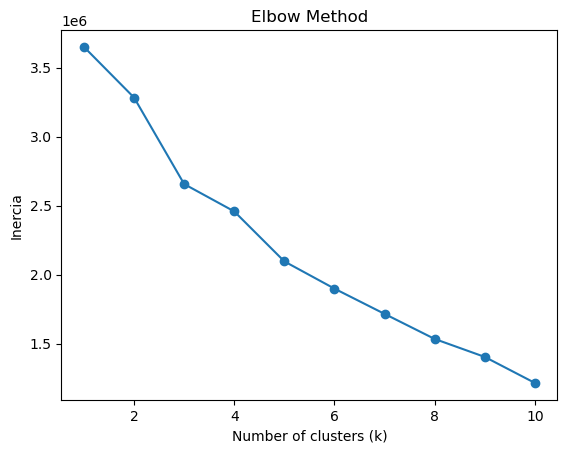

In [7]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(df_StandardScaler)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inercia')
plt.title('Elbow Method')
plt.show()

by looking at the graph and using the Elbow Method, the number of clusters would be 3.

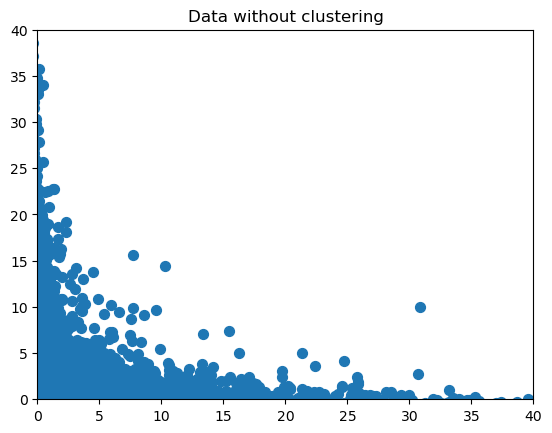

In [37]:
plt.scatter(df_StandardScaler.iloc[:, 0],df_StandardScaler.iloc[:, 2], s=50)
plt.ylim(0,40)
plt.xlim(0,40)
plt.title("Data without clustering")
plt.show()

In [9]:
#apply kmean with StandardScaler
kmeans1 = KMeans(n_clusters=3, random_state=0)
kmeans1.fit(df_StandardScaler)
labels1 = kmeans1.labels_
centroids1 = kmeans1.cluster_centers_

#apply kmean with StandardScaler
kmeans2 = KMeans(n_clusters=3, random_state=0)
kmeans2.fit(df_MinMaxScaler)
labels2 = kmeans2.labels_
centroids2 = kmeans2.cluster_centers_

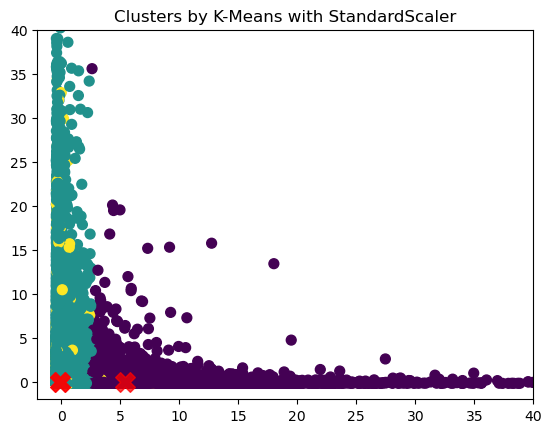

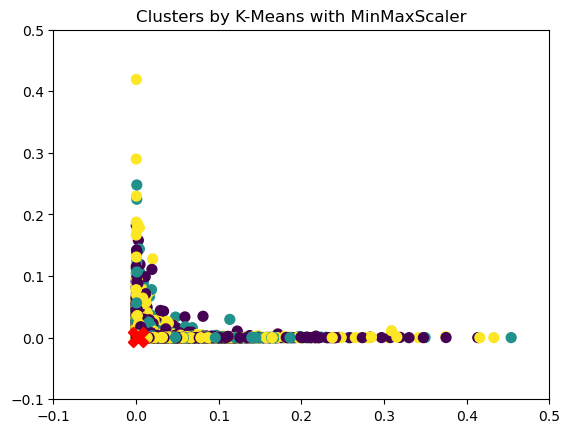

In [11]:
plt.figure(1) 
plt.scatter(df_StandardScaler.iloc[:, 0], df_StandardScaler.iloc[:, 1], c=labels1, s=50, cmap='viridis')
plt.scatter(centroids1[:, 0], centroids1[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.ylim(-2, 40)
plt.xlim(-2, 40)
plt.title("Clusters by K-Means with StandardScaler")
plt.show()

plt.figure(2)
plt.scatter(df_MinMaxScaler.iloc[:, 0], df_MinMaxScaler.iloc[:, 1], c=labels2, s=50, cmap='viridis')
plt.scatter(centroids2[:, 0], centroids2[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.ylim(-0.1, 0.5)
plt.xlim(-0.1, 0.5)
plt.title("Clusters by K-Means with MinMaxScaler")
plt.show()

# DBSCAN Application

since there is a lot of data, we proceed to divide it into smaller chunks, apply DBSCAN to each chunk separately and then combine the results.

In [12]:
from sklearn.cluster import DBSCAN

chunks1 = np.array_split(df_StandardScaler, 10)
chunks2 = np.array_split(df_MinMaxScaler, 10)

all_labels1 = []
for chunk in chunks1:
    dbscan1 = DBSCAN(eps=0.3, min_samples=4, algorithm='ball_tree')
    labels1 = dbscan1.fit_predict(chunk)
    all_labels1.append(labels1)

all_labels1 = np.concatenate(all_labels1)

all_labels2 = []
for chunk in chunks2:
    dbscan2 = DBSCAN(eps=0.3, min_samples=5, algorithm='ball_tree')
    labels2 = dbscan2.fit_predict(chunk)
    all_labels2.append(labels2)

all_labels2 = np.concatenate(all_labels2)

C:\Users\Javier\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


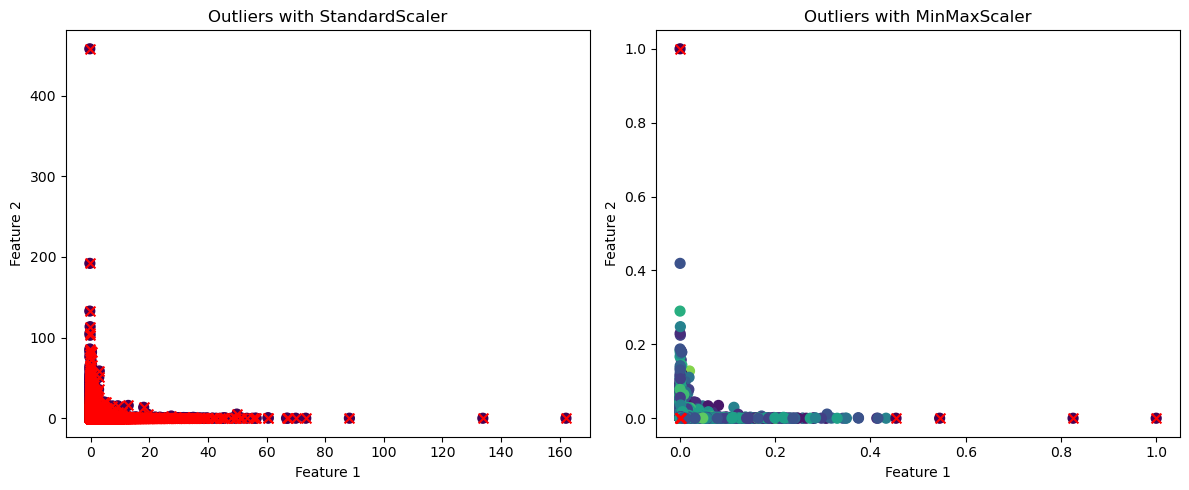

In [13]:
outliers1 = df_StandardScaler[all_labels1 == -1]
outliers2 = df_MinMaxScaler[all_labels2 == -1]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_StandardScaler.iloc[:, 0], df_StandardScaler.iloc[:, 1], c=all_labels1, s=50, cmap='viridis')
plt.scatter(outliers1.iloc[:, 0], outliers1.iloc[:, 1], c='red', s=50, label='Outliers', marker='x')
plt.title("Outliers with StandardScaler")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Subplot 2: df_MinMaxScaler
plt.subplot(1, 2, 2)
plt.scatter(df_MinMaxScaler.iloc[:, 0], df_MinMaxScaler.iloc[:, 1], c=all_labels2, s=50, cmap='viridis')
plt.scatter(outliers2.iloc[:, 0], outliers2.iloc[:, 1], c='red', s=50, label='Outliers', marker='x')
plt.title("Outliers with MinMaxScaler")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Mostrar la figura
plt.tight_layout()
plt.show()

# Clustering Evaluation

In [14]:
df['Cluster_KMeans1'] = kmeans1.fit_predict(df_StandardScaler)
df['Cluster_KMeans2'] = kmeans2.fit_predict(df_MinMaxScaler)

df['Outlier1_DBSCAN'] = np.where(all_labels1 == -1, 1, 0) 
df['Outlier2_DBSCAN'] = np.where(all_labels2 == -1, 1, 0)

df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud,Cluster_KMeans1,Cluster_KMeans2,Outlier1_DBSCAN,Outlier2_DBSCAN
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0,1,2,0,0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0,1,1,0,0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0,1,0,0,0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0,1,2,0,0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0,1,2,0,0


In [45]:
table1=df.groupby(['Cluster_KMeans1','fraud']).size().reset_index(name='count')
print(table1)
cls1 = (table1.iloc[1,2]/(table1.iloc[1,2]+table1.iloc[0,2]))*100
cls2 = (table1.iloc[3,2]/(table1.iloc[3,2]+table1.iloc[2,2]))*100
cls3 = (table1.iloc[5,2]/(table1.iloc[5,2]+table1.iloc[4,2]))*100
print(f"% fraud Cluster 1 with StandardScaler: {cls1}")
print(f"% fraud Cluster 2 with StandardScaler: {cls2}")
print(f"% fraud Cluster 3 with StandardScaler: {cls3}")

   Cluster_KMeans1  fraud   count
0                0    0.0    9075
1                0    1.0    7036
2                1    0.0  883846
3                1    1.0   47428
4                2    0.0   19676
5                2    1.0   32939
% fraud Cluster 1 with StandardScaler: 43.67202532431258
% fraud Cluster 2 with StandardScaler: 5.0928083464157705
% fraud Cluster 3 with StandardScaler: 62.60382020336406


In [47]:
table2=df.groupby(['Cluster_KMeans2','fraud']).size().reset_index(name='count')
print(table2)
cls1 = (table2.iloc[1,2]/(table2.iloc[1,2]+table2.iloc[0,2]))*100
cls2 = (table2.iloc[3,2]/(table2.iloc[3,2]+table2.iloc[2,2]))*100
cls3 = (table2.iloc[5,2]/(table2.iloc[5,2]+table2.iloc[4,2]))*100
print(f"% fraud Cluster 1 with MinMaxScaler: {cls1}")
print(f"% fraud Cluster 2 with MinMaxScaler: {cls2}")
print(f"% fraud Cluster 3 with MinMaxScaler: {cls3}")

   Cluster_KMeans2  fraud   count
0                0    0.0  361537
1                0    1.0   61112
2                1    0.0  223071
3                1    1.0    3881
4                2    0.0  327989
5                2    1.0   22410
% fraud Cluster 1 with MinMaxScaler: 14.459279449377615
% fraud Cluster 2 with MinMaxScaler: 1.7100532271141036
% fraud Cluster 3 with MinMaxScaler: 6.3955661973921165


In [49]:
table3=df.groupby(['Outlier1_DBSCAN','fraud']).size().reset_index(name='count')
print(table3)
out1 = (table3.iloc[3,2]/(table3.iloc[3,2]+table3.iloc[2,2]))*100
print(f"% fraud Outliers with StandardScaler: {out1}")

   Outlier1_DBSCAN  fraud   count
0                0    0.0  902297
1                0    1.0   79251
2                1    0.0   10300
3                1    1.0    8152
% fraud Outliers with StandardScaler: 44.179492737914586


In [51]:
table4=df.groupby(['Outlier2_DBSCAN','fraud']).size().reset_index(name='count')
print(table4)
out2 = (table4.iloc[3,2]/(table4.iloc[3,2]+table4.iloc[2,2]))*100
print(f"% fraud Outliers with MinMaxScaler: {out2}")

   Outlier2_DBSCAN  fraud   count
0                0    0.0  912591
1                0    1.0   87400
2                1    0.0       6
3                1    1.0       3
% fraud Outliers with MinMaxScaler: 33.33333333333333


With k-means and DBSCAN it is observed that the best transformation was StandardScaler, but this may be because the other transformation would need other parameters in k-means and DBSCAN. In the k-means we see that cluster 3 and cluster 1 classifies fraud better in accuracy while the DBSCAN outliers is similar to cluster 1 with good % of accuracy and would be ideal for alerting these transactions since few transactions would be reviewed even though it captures less than 10% of the fraud.

This dataset is labeled fraud and the clusters can be used as additional features to train a classification model.

As another recommendation for this exercise, you can also use the PCA, t-SNE or UMAP transformation to visualize and analyze the data in a lower dimensional space so that DBSCAN has less trouble finding the distance between the points.